# # 🌐 Multilingual Phishing Email Detection using mBERT
# 
# This notebook trains a multilingual BERT model (mBERT) to detect phishing emails in **English, Hindi, and Nepali**.
# 
# ---

# ## 1. Setup & Imports


In [87]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, confusion_matrix, classification_report
from transformers import BertTokenizer, BertForSequenceClassification, Trainer, TrainingArguments, DataCollatorWithPadding
from datasets import Dataset

from langdetect import detect, DetectorFactory
DetectorFactory.seed = 42

os.makedirs("figures", exist_ok=True)
print("Setup complete.")

Setup complete.


# ## 2. Load & Explore Data
# 
# Assuming you already have a DataFrame `df` with columns `text` and `label`.
# We'll sample 15,000 rows as shown in your notebook.
|

Data shape: (15000, 4)

First few rows:
                                                text     label language  \
0  हाम्रो न्यूजलेटरमा स्वागत छ! यस महिनाका अपडेटह...      Safe       NP   
1  Hello, नए डिवाइस से असामान्य लॉगिन। यदि आपने न...  Phishing       HI   
2  Your subscription has been renewed successfull...      Safe       EN   
3  सूचना: Action required: Please update your con...  Phishing       NP   
4  Dear user, we detected suspicious activity on ...  Phishing       EN   

                                     source  
0                                 synthetic  
1                                 synthetic  
2                                 synthetic  
3  SpamAssassin (public corpus) (sanitized)  
4                                 synthetic  


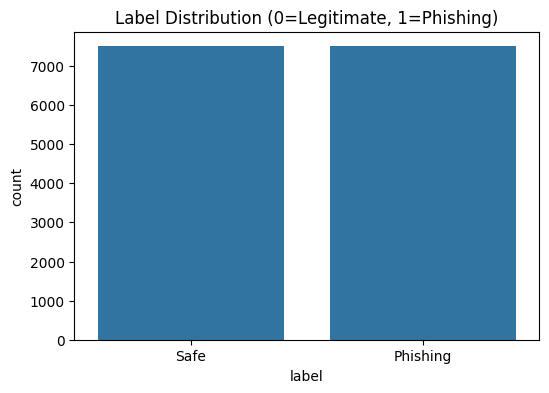

In [88]:
# Load your data (replace with your actual loading code)
# If you already have df from previous cells, you can skip this.
# Example:
df = pd.read_csv("combined_phishing_dataset_15000.csv")
# df = df.sample(n=15000, random_state=42).reset_index(drop=True)

# For demonstration, we'll assume df already exists.
# Let's check shape
print("Data shape:", df.shape)
print("\nFirst few rows:")
print(df.head())

# %%
# Quick check of label distribution
plt.figure(figsize=(6,4))
sns.countplot(data=df, x='label')
plt.title('Label Distribution (0=Legitimate, 1=Phishing)')
plt.savefig("figures/label_distribution.png", dpi=150, bbox_inches='tight')
plt.show()


# ## 3. Language Detection (Exploratory)
# 
# We'll detect the language of each email to see the composition (English/Hindi/Nepali). This helps understand if the model needs multilingual capacity.

Language distribution in sampled data:
lang
en    3660
hi     866
ne     474
Name: count, dtype: int64


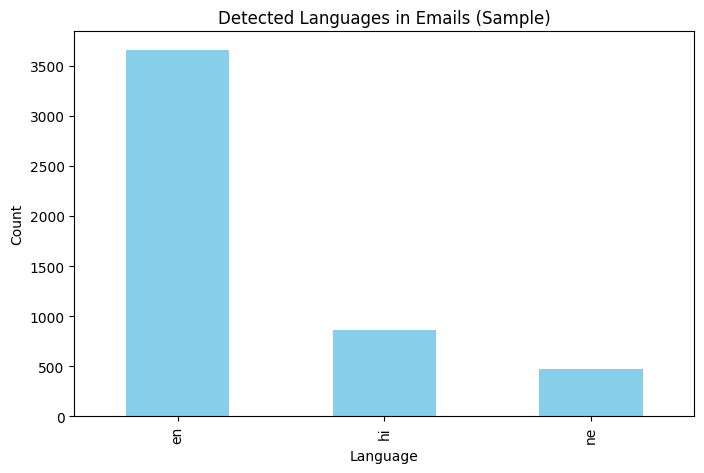

In [89]:
def detect_lang(text):
    try:
        return detect(text)
    except:
        return 'unknown'

# Sample a subset for speed (e.g., 5000 rows)
sample_df = df.sample(min(5000, len(df)), random_state=42)
sample_df['lang'] = sample_df['text'].apply(detect_lang)

lang_counts = sample_df['lang'].value_counts()
print("Language distribution in sampled data:")
print(lang_counts)

# Plot language distribution
plt.figure(figsize=(8,5))
lang_counts.plot(kind='bar', color='skyblue')
plt.title('Detected Languages in Emails (Sample)')
plt.xlabel('Language')
plt.ylabel('Count')
plt.savefig("figures/language_distribution.png", dpi=150, bbox_inches='tight')
plt.show()

# ## 4. Train/Validation/Test Split (70/10/20)


In [90]:
label_mapping = {
    'Safe': 0,        # legitimate
    'Phishing': 1,    # phishing
    # add other values if needed, e.g., 'Legitimate': 0, 'Spam': 1, etc.
}

# Apply mapping
df['label'] = df['label'].map(label_mapping)
# Split features and labels
X = df['text'].tolist()
y = df['label'].astype(int).tolist()

# First, split out 20% test data
X_train_val, X_test, y_train_val, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Then split remaining 80% into 70% train and 10% val (12.5% of the 80% = 10% of total)
X_train, X_val, y_train, y_val = train_test_split(
    X_train_val, y_train_val,
    test_size=0.125,  # 0.125 * 0.8 = 0.1
    random_state=42, stratify=y_train_val
)

print(f"Train size: {len(X_train)}")
print(f"Validation size: {len(X_val)}")
print(f"Test size: {len(X_test)}")


Train size: 10500
Validation size: 1500
Test size: 3000


# ## 5. Tokenization with Multilingual BERT
# 
# We use `bert-base-multilingual-cased` which supports over 100 languages including Hindi and Nepali.

In [91]:
tokenizer = BertTokenizer.from_pretrained("bert-base-multilingual-cased")

def tokenize(texts):
    return tokenizer(texts, truncation=True, padding=True, max_length=512)

train_enc = tokenize(X_train)
val_enc = tokenize(X_val)
test_enc = tokenize(X_test)

train_dataset = Dataset.from_dict({
    'input_ids': train_enc['input_ids'],
    'attention_mask': train_enc['attention_mask'],
    'labels': y_train
})
val_dataset = Dataset.from_dict({
    'input_ids': val_enc['input_ids'],
    'attention_mask': val_enc['attention_mask'],
    'labels': y_val
})
test_dataset = Dataset.from_dict({
    'input_ids': test_enc['input_ids'],
    'attention_mask': test_enc['attention_mask'],
    'labels': y_test
})

print("Tokenization done.")

Tokenization done.


# compute class Weight (to penalize false negative more)

In [92]:
from sklearn.utils.class_weight import compute_class_weight
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

classes = np.unique(y_train)
weights = compute_class_weight('balanced', classes=classes, y=y_train)
weight_tensor = torch.tensor(weights, dtype=torch.float32).to(device)
# Boost weight for class 1 (phishing) by 1.5x to penalize false negatives more
weight_tensor[1] = weight_tensor[1] * 1.2

print("Class weights (0=Legitimate, 1=Phishing):", weight_tensor.cpu().numpy())

Class weights (0=Legitimate, 1=Phishing): [1.  1.2]


# Model with Custom Weighted Loss (via Trainer override)

In [93]:
model = BertForSequenceClassification.from_pretrained(
    "bert-base-multilingual-cased",
    num_labels=2
).to(device)

class WeightedLossTrainer(Trainer):
    def compute_loss(self, model, inputs, return_outputs=False, num_items_in_batch=None):
        labels = inputs.get("labels")
        outputs = model(**inputs)
        logits = outputs.logits
        loss_fct = torch.nn.CrossEntropyLoss(weight=weight_tensor)
        loss = loss_fct(logits, labels)
        return (loss, outputs) if return_outputs else loss

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: bert-base-multilingual-cased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


# ## 8. Training Arguments & Trainer


In [94]:
training_args = TrainingArguments(
    output_dir='./results_weighted',
    eval_strategy="epoch",
    save_strategy="epoch",
    save_total_limit=2,
    learning_rate=1.2e-5,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    gradient_accumulation_steps=2,
    num_train_epochs=3,
    weight_decay=0.01,
    load_best_model_at_end=True,
    metric_for_best_model="f1",
    greater_is_better=True,
    report_to="none"
)

data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

def compute_metrics(eval_pred):
    preds = eval_pred.predictions.argmax(-1)
    labels = eval_pred.label_ids
    acc = accuracy_score(labels, preds)
    precision, recall, f1, _ = precision_recall_fscore_support(labels, preds, average='binary')
    return {'accuracy': acc, 'precision': precision, 'recall': recall, 'f1': f1}

trainer = WeightedLossTrainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    data_collator=data_collator,
    compute_metrics=compute_metrics
)

# ## 9. Train the Model


In [95]:
trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,0.481580,0.191067,0.854667,0.825980,0.898667,0.860792
2,0.437191,0.190245,0.880667,1.000000,0.761333,0.864497
3,0.415157,0.190900,0.858000,0.816254,0.924000,0.866792


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

[transformers] There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.atte

TrainOutput(global_step=1971, training_loss=0.44050634530278887, metrics={'train_runtime': 340.4861, 'train_samples_per_second': 92.515, 'train_steps_per_second': 5.789, 'total_flos': 1035999780480000.0, 'train_loss': 0.44050634530278887, 'epoch': 3.0})

# ## 10. Plot Training Loss & Validation curven

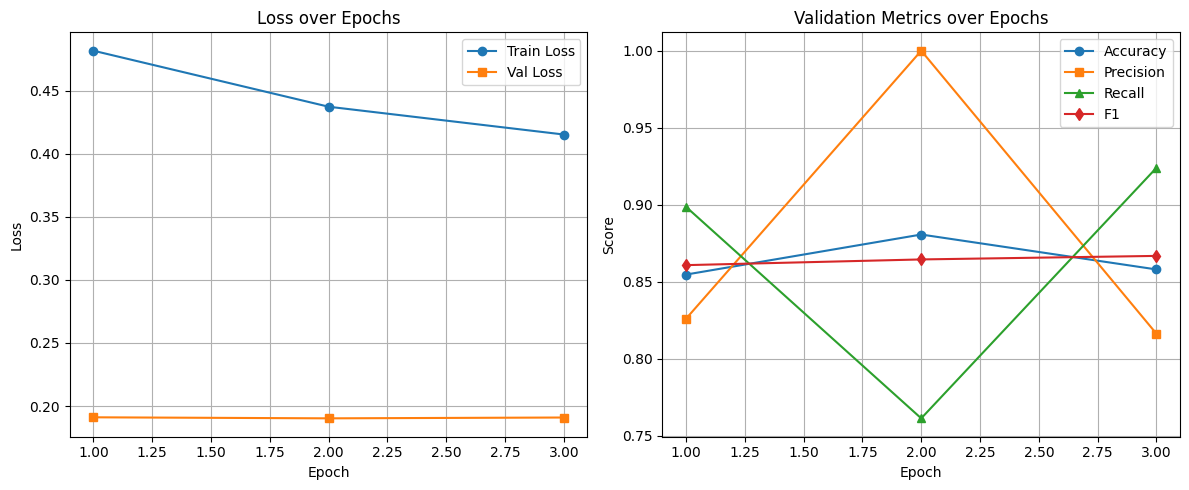

In [96]:
log_history = trainer.state.log_history

train_loss = []
val_loss = []
val_acc = []
val_prec = []
val_rec = []
val_f1 = []
epochs = []

for entry in log_history:
    if 'loss' in entry:
        train_loss.append(entry['loss'])
    if 'eval_loss' in entry:
        val_loss.append(entry['eval_loss'])
        val_acc.append(entry['eval_accuracy'])
        val_prec.append(entry['eval_precision'])
        val_rec.append(entry['eval_recall'])
        val_f1.append(entry['eval_f1'])
        epochs.append(len(val_loss))

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(epochs, train_loss[:len(epochs)], marker='o', label='Train Loss')
plt.plot(epochs, val_loss, marker='s', label='Val Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Loss over Epochs')
plt.legend()
plt.grid(True)

plt.subplot(1,2,2)
plt.plot(epochs, val_acc, marker='o', label='Accuracy')
plt.plot(epochs, val_prec, marker='s', label='Precision')
plt.plot(epochs, val_rec, marker='^', label='Recall')
plt.plot(epochs, val_f1, marker='d', label='F1')
plt.xlabel('Epoch')
plt.ylabel('Score')
plt.title('Validation Metrics over Epochs')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.savefig("figures/training_curves.png", dpi=150)
plt.show()

# Threshold tuning on validation test

In [97]:
val_results = trainer.predict(val_dataset)
val_probs = torch.nn.functional.softmax(torch.tensor(val_results.predictions), dim=1)[:, 1].numpy()
y_val_true = val_dataset['labels']

thresholds = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7]
print("Threshold | Precision | Recall | F1")
print("-" * 40)

best_f1 = 0
best_thresh = 0.5

for thresh in thresholds:
    preds = (val_probs >= thresh).astype(int)
    prec = precision_score(y_val_true, preds)
    rec = recall_score(y_val_true, preds)
    f1 = f1_score(y_val_true, preds)
    print(f"{thresh:.1f}       | {prec:.4f}   | {rec:.4f} | {f1:.4f}")
    if f1 > best_f1:
        best_f1 = f1
        best_thresh = thresh

print(f"\nBest threshold: {best_thresh:.1f} (F1 = {best_f1:.4f})")

Threshold | Precision | Recall | F1
----------------------------------------
0.1       | 0.7599   | 1.0000 | 0.8636
0.2       | 0.7599   | 1.0000 | 0.8636
0.3       | 0.7599   | 1.0000 | 0.8636
0.4       | 0.7599   | 1.0000 | 0.8636
0.5       | 0.8163   | 0.9240 | 0.8668
0.6       | 1.0000   | 0.7613 | 0.8645
0.7       | 1.0000   | 0.7613 | 0.8645

Best threshold: 0.5 (F1 = 0.8668)


# ## 11. Evaluate on Test Set


Final Test Evaluation:
Accuracy:  0.8470
Precision: 0.8017
Recall:    0.9220
F1 Score:  0.8577

Classification Report:
              precision    recall  f1-score   support

  Legitimate       0.91      0.77      0.83      1500
    Phishing       0.80      0.92      0.86      1500

    accuracy                           0.85      3000
   macro avg       0.85      0.85      0.85      3000
weighted avg       0.85      0.85      0.85      3000



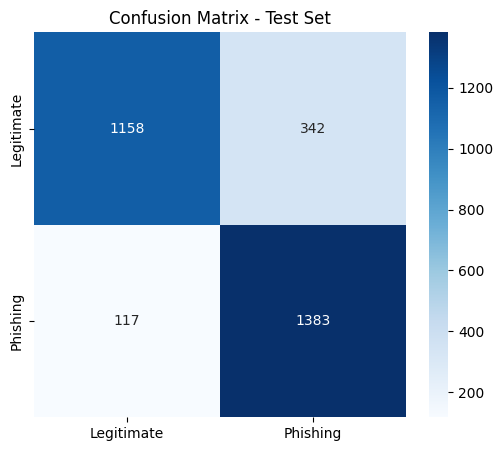

In [98]:
test_results = trainer.predict(test_dataset)
test_probs = torch.nn.functional.softmax(torch.tensor(test_results.predictions), dim=1)[:, 1].numpy()
y_test_true = test_dataset['labels']

y_test_pred = (test_probs >= best_thresh).astype(int)

print("Final Test Evaluation:")
print(f"Accuracy:  {accuracy_score(y_test_true, y_test_pred):.4f}")
print(f"Precision: {precision_score(y_test_true, y_test_pred):.4f}")
print(f"Recall:    {recall_score(y_test_true, y_test_pred):.4f}")
print(f"F1 Score:  {f1_score(y_test_true, y_test_pred):.4f}")
print("\nClassification Report:")
print(classification_report(y_test_true, y_test_pred, target_names=['Legitimate', 'Phishing']))

# Confusion Matrix
cm = confusion_matrix(y_test_true, y_test_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Legitimate', 'Phishing'],
            yticklabels=['Legitimate', 'Phishing'])
plt.title('Confusion Matrix - Test Set')
plt.savefig("figures/confusion_matrix.png", dpi=150)
plt.show()

# Prediction Function with Adjustable Threshold

In [99]:
def predict_phishing(text, threshold=best_thresh):
    model.eval()
    inputs = tokenizer(text, return_tensors="pt", truncation=True, padding=True, max_length=512)
    inputs = {k: v.to(device) for k, v in inputs.items()}
    with torch.no_grad():
        logits = model(**inputs).logits
        prob = torch.softmax(logits, dim=1)[0][1].item()
    return "Phishing" if prob >= threshold else "Legitimate", prob

# Example
sample = "Your account has been compromised. Verify now at http://fake-link.com"
label, conf = predict_phishing(sample)
print(f"Prediction: {label} (confidence: {conf:.4f})")

Prediction: Phishing (confidence: 0.5106)


# ## 12. Save Final Model & Tokenizer


In [100]:
model.save_pretrained("./final_multilingual_model")
tokenizer.save_pretrained("./final_multilingual_model")
print("Model saved to './final_multilingual_model'")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Model saved to './final_multilingual_model'


# ## 14. (Optional) Language-Specific Performance Analysis
# 
# If you want to see how the model performs on each language, you can run inference on the test set with language labels.


In [101]:
# Sample test set to see performance per language
test_df = pd.DataFrame({'text': X_test, 'true': y_test, 'pred': y_test_pred})
sample_df = test_df.sample(min(1000, len(test_df)), random_state=42)
sample_df['lang'] = sample_df['text'].apply(lambda x: detect(str(x)) if len(str(x))>20 else 'unknown')

print("Performance by detected language:")
for lang in sample_df['lang'].unique():
    sub = sample_df[sample_df['lang'] == lang]
    if len(sub) > 20:
        acc = (sub['true'] == sub['pred']).mean()
        print(f"{lang}: {acc:.4f} (n={len(sub)})")

Performance by detected language:
en: 0.7933 (n=750)
hi: 1.0000 (n=153)
ne: 1.0000 (n=97)


In [102]:
# First, add language labels to test set (similar to section 3)
test_df = pd.DataFrame({'text': X_test, 'label': y_test})
test_df['lang'] = test_df['text'].apply(detect_lang)

# Predict on test set using the trained model (already loaded in trainer)
test_preds = trainer.predict(test_dataset).predictions.argmax(axis=1)
test_df['pred'] = test_preds

# Compute per-language accuracy
print("\n=== Performance by Detected Language ===")
for lang in test_df['lang'].unique():
    subset = test_df[test_df['lang'] == lang]
    if len(subset) > 10:
        acc_lang = (subset['label'] == subset['pred']).mean()
        print(f"{lang}: {acc_lang:.4f} (n={len(subset)})")
    else:
        print(f"{lang}: insufficient samples ({len(subset)})")

# %%
print("Notebook completed successfully.")


=== Performance by Detected Language ===
hi: 1.0000 (n=475)
en: 0.7955 (n=2244)
ne: 1.0000 (n=281)
Notebook completed successfully.
